objectif : resampler le dataset pour tenter de regler le pb de reequilibrage

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset_test = 'test-english'
dataset_train = 'training-english'
dataset_valid = 'validation-english'

labels = 'labels'
# labels = 'subclasses_labels'

In [3]:
sentences_test_file_path = f"datasets/valueeval24/{dataset_test}/sentences.tsv"
sentences_train_file_path = f"datasets/valueeval24/{dataset_train}/sentences.tsv"
sentences_valid_file_path = f"datasets/valueeval24/{dataset_valid}/sentences.tsv"
labels_file_path_test = f"datasets/valueeval24/{dataset_test}/{labels}.tsv"
labels_file_path_train = f"datasets/valueeval24/{dataset_train}/{labels}.tsv"
labels_file_path_valid = f"datasets/valueeval24/{dataset_valid}/{labels}.tsv"

In [4]:
sentences_test_df = pd.read_csv(sentences_test_file_path, sep="\t")
sentences_train_df = pd.read_csv(sentences_train_file_path, sep="\t")
sentences_valid_df = pd.read_csv(sentences_valid_file_path, sep="\t")
labels_test_df = pd.read_csv(labels_file_path_test, sep="\t")
labels_train_df = pd.read_csv(labels_file_path_train, sep="\t")
labels_valid_df = pd.read_csv(labels_file_path_valid, sep="\t")
dataset_test_df = pd.merge(sentences_test_df, labels_test_df, on=["Text-ID", "Sentence-ID"])
dataset_train_df = pd.merge(sentences_train_df, labels_train_df, on=["Text-ID", "Sentence-ID"])
dataset_valid_df = pd.merge(sentences_valid_df, labels_valid_df, on=["Text-ID", "Sentence-ID"])

In [5]:
dataset_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44758 entries, 0 to 44757
Data columns (total 41 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Text-ID                                 44758 non-null  object 
 1   Sentence-ID                             44758 non-null  int64  
 2   Text                                    44758 non-null  object 
 3   Self-direction: thought attained        44758 non-null  float64
 4   Self-direction: thought constrained     44758 non-null  float64
 5   Self-direction: action attained         44758 non-null  float64
 6   Self-direction: action constrained      44758 non-null  float64
 7   Stimulation attained                    44758 non-null  float64
 8   Stimulation constrained                 44758 non-null  float64
 9   Hedonism attained                       44758 non-null  float64
 10  Hedonism constrained                    44758 non-null  fl

In [6]:
labels_list = ['Self-direction: thought attained',
       'Self-direction: thought constrained',
       'Self-direction: action attained', 'Self-direction: action constrained',
       'Stimulation attained', 'Stimulation constrained', 'Hedonism attained',
       'Hedonism constrained', 'Achievement attained',
       'Achievement constrained', 'Power: dominance attained',
       'Power: dominance constrained', 'Power: resources attained',
       'Power: resources constrained', 'Face attained', 'Face constrained',
       'Security: personal attained', 'Security: personal constrained',
       'Security: societal attained', 'Security: societal constrained',
       'Tradition attained', 'Tradition constrained',
       'Conformity: rules attained', 'Conformity: rules constrained',
       'Conformity: interpersonal attained',
       'Conformity: interpersonal constrained', 'Humility attained',
       'Humility constrained', 'Benevolence: caring attained',
       'Benevolence: caring constrained',
       'Benevolence: dependability attained',
       'Benevolence: dependability constrained',
       'Universalism: concern attained', 'Universalism: concern constrained',
       'Universalism: nature attained', 'Universalism: nature constrained',
       'Universalism: tolerance attained',
       'Universalism: tolerance constrained']

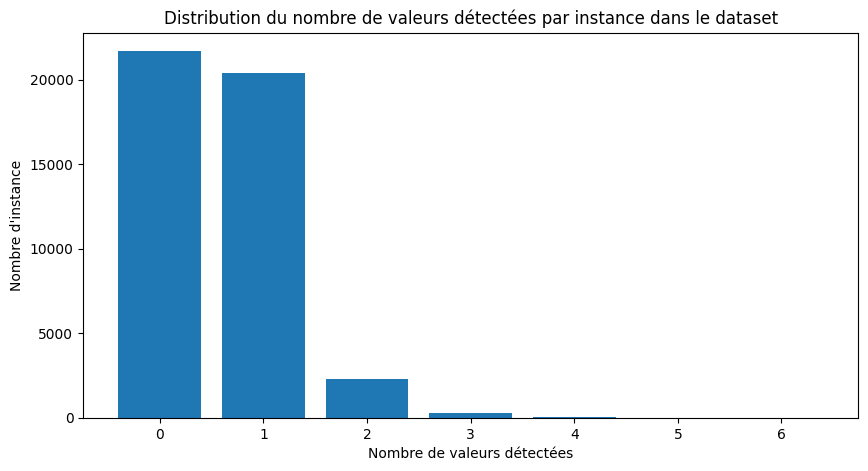

In [11]:
ones_per_row = dataset_train_df[labels_list].sum(axis=1)

counts = ones_per_row.value_counts().sort_index()
plt.figure(figsize=(10, 5))
plt.bar(counts.index, counts.values)
plt.xlabel("Nombre de valeurs détectées")
plt.ylabel("Nombre d'instance")
plt.title("Distribution du nombre de valeurs détectées par instance dans le dataset")
plt.show()

In [12]:
dataset_train_df['No values'] = (dataset_train_df[labels_list].sum(axis=1) == 0).astype(int)

In [13]:
labels_list.append('No values')

In [14]:
df_train = dataset_train_df[dataset_train_df[labels_list].sum(axis=1) > 0]

In [15]:
for col in labels_list:
    print(df_train[col].value_counts())

Self-direction: thought attained
0.0    44259
1.0      447
0.5       52
Name: count, dtype: int64
Self-direction: thought constrained
0.0    44626
1.0       80
0.5       52
Name: count, dtype: int64
Self-direction: action attained
0.0    43402
1.0     1256
0.5      100
Name: count, dtype: int64
Self-direction: action constrained
0.0    44397
1.0      261
0.5      100
Name: count, dtype: int64
Stimulation attained
0.0    43712
1.0      971
0.5       75
Name: count, dtype: int64
Stimulation constrained
0.0    44557
1.0      126
0.5       75
Name: count, dtype: int64
Hedonism attained
0.0    44479
1.0      264
0.5       15
Name: count, dtype: int64
Hedonism constrained
0.0    44636
1.0      107
0.5       15
Name: count, dtype: int64
Achievement attained
0.0    42680
1.0     1925
0.5      153
Name: count, dtype: int64
Achievement constrained
0.0    43808
1.0      797
0.5      153
Name: count, dtype: int64
Power: dominance attained
0.0    43024
1.0     1487
0.5      247
Name: count, dtype: 

In [16]:
class_distribution = df_train.iloc[:, 2:].sum(axis=0).apply(pd.to_numeric, errors='coerce')
print(class_distribution)

Text                                          NaN
Self-direction: thought attained            473.0
Self-direction: thought constrained         106.0
Self-direction: action attained            1306.0
Self-direction: action constrained          311.0
Stimulation attained                       1008.5
Stimulation constrained                     163.5
Hedonism attained                           271.5
Hedonism constrained                        114.5
Achievement attained                       2001.5
Achievement constrained                     873.5
Power: dominance attained                  1610.5
Power: dominance constrained                461.5
Power: resources attained                  1384.5
Power: resources constrained                852.5
Face attained                               415.5
Face constrained                            396.5
Security: personal attained                 319.5
Security: personal constrained              588.5
Security: societal attained                1699.5


C:\Users\eloua\AppData\Local\Temp\ipykernel_18664\2042922838.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_distribution.index, y=class_distribution.values, palette="viridis")


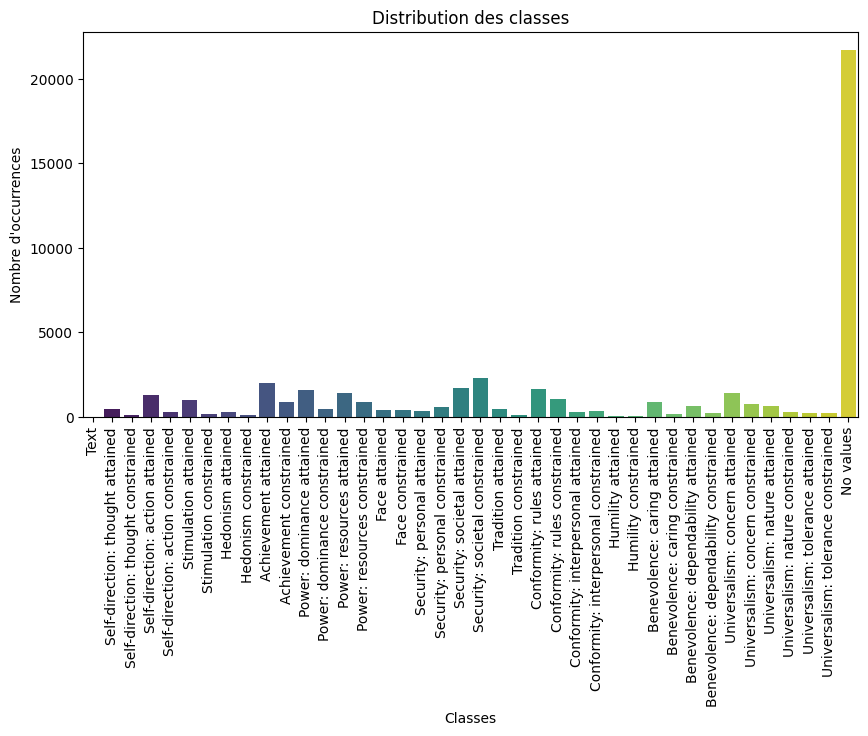

In [18]:
plt.figure(figsize=(10, 5))
sns.barplot(x=class_distribution.index, y=class_distribution.values, palette="viridis")

plt.xticks(rotation=90) 
plt.xlabel("Classes")
plt.ylabel("Nombre d'occurrences")
plt.title("Distribution des classes")
plt.show()

In [12]:
target_count = 200
epsilon = 50

# Classes à sur-échantillonner et sous-échantillonner
to_oversample = class_distribution[class_distribution < target_count].index
to_undersample = class_distribution[class_distribution > target_count].index

print("Classes à sur-échantillonner :", to_oversample)
print("Classes à sous-échantillonner :", to_undersample)

Classes à sur-échantillonner : Index(['Self-direction: thought constrained', 'Stimulation constrained',
       'Hedonism constrained', 'Tradition constrained', 'Humility attained',
       'Humility constrained', 'Benevolence: caring constrained',
       'Benevolence: dependability constrained'],
      dtype='object')
Classes à sous-échantillonner : Index(['Self-direction: thought attained', 'Self-direction: action attained',
       'Self-direction: action constrained', 'Stimulation attained',
       'Hedonism attained', 'Achievement attained', 'Achievement constrained',
       'Power: dominance attained', 'Power: dominance constrained',
       'Power: resources attained', 'Power: resources constrained',
       'Face attained', 'Face constrained', 'Security: personal attained',
       'Security: personal constrained', 'Security: societal attained',
       'Security: societal constrained', 'Tradition attained',
       'Conformity: rules attained', 'Conformity: rules constrained',
       

In [13]:
df = df_train.copy()

In [14]:
from sklearn.utils import resample

balanced_data = []

for column in to_undersample:
    positive_samples = df_train[df_train[column] == 1]
    
    undersampled = resample(
        positive_samples,
        replace=False, 
        n_samples=target_count, 
    )
    
    balanced_data.append(undersampled)

for column in to_oversample:
    positive_samples = df_train[df_train[column] == 1]
    
    oversampled = resample(
        positive_samples,
        replace=True,  
        n_samples=target_count,
    )
    
    balanced_data.append(oversampled)


In [15]:
df_balanced = pd.concat(balanced_data)
df_balanced = df_balanced.sample(frac=1).reset_index(drop=True)

print(df_balanced.iloc[:, 2:].sum(axis=0))

Text                                      Answering the questions of the press members, ...
Self-direction: thought attained                                                      240.0
Self-direction: thought constrained                                                   207.0
Self-direction: action attained                                                       327.0
Self-direction: action constrained                                                    218.0
Stimulation attained                                                                  281.5
Stimulation constrained                                                               205.5
Hedonism attained                                                                     233.5
Hedonism constrained                                                                  217.5
Achievement attained                                                                  335.0
Achievement constrained                                                         

In [16]:
df_balanced.to_csv('resampling_train_200_nv.csv')

Text                                      Apparently, Netanyahu&#39;s capacity for work ...
Self-direction: thought attained                                                      240.0
Self-direction: thought constrained                                                   207.0
Self-direction: action attained                                                       327.0
Self-direction: action constrained                                                    218.0
Stimulation attained                                                                  281.5
Stimulation constrained                                                               205.5
Hedonism attained                                                                     233.5
Hedonism constrained                                                                  217.5
Achievement attained                                                                  335.0
Achievement constrained                                                         

C:\Users\eloua\AppData\Local\Temp\ipykernel_18664\3815219156.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_distribution.index, y=class_distribution.values, palette="viridis")


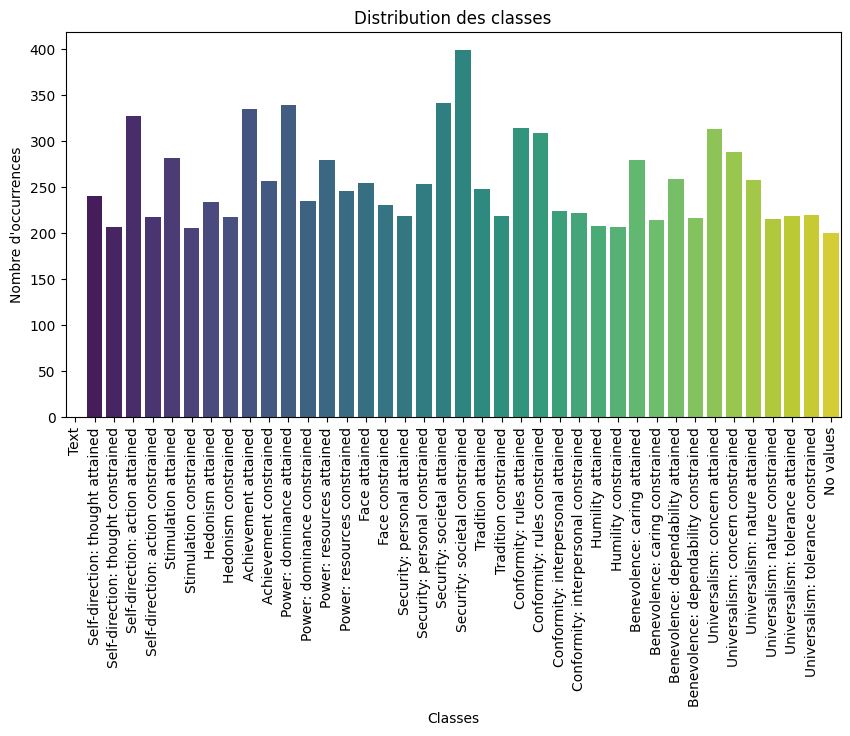

In [22]:
df = pd.read_csv('resampling_train_200_nv.csv')
df.drop(columns=["Sentence-ID"], inplace=True)
df = df.sample(frac=1).reset_index(drop=True)

print(df.iloc[:, 2:].sum(axis=0))
class_distribution = df.iloc[:, 2:].sum(axis=0).apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(10, 5))
sns.barplot(x=class_distribution.index, y=class_distribution.values, palette="viridis")
plt.xticks(rotation=90) 
plt.xlabel("Classes")
plt.ylabel("Nombre d'occurrences")
plt.title("Distribution des classes")
plt.show()
